# CatBoost Classifier

In [1]:
# imports
%pip install pandas scikit-learn catboost

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from catboost import CatBoostClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, f1_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score
import numpy as np
import matplotlib.pyplot as plt

Note: you may need to restart the kernel to use updated packages.


## Data preparation

In [2]:
df_challenger = pd.read_csv('../datasets/challenger_dataset.csv')

df_challenger.head()

,timestamp,BLUE.HEXTECH_DRAGON.kills,BLUE.WATER_DRAGON.kills,BLUE.FIRE_DRAGON.kills,BLUE.EARTH_DRAGON.kills,BLUE.AIR_DRAGON.kills,BLUE.CHEMTECH_DRAGON.kills,BLUE.ELDER_DRAGON.kills,BLUE.RIFTHERALD.kills,BLUE.BARON_NASHOR.kills,...,soul_Mountain,soul_Ocean,BLUE.minionRatio,RED.minionRatio,BLUE.totalGoldRatio,RED.totalGoldRatio,BLUE.levelRatio,RED.levelRatio,BLUE.kda,RED.kda
0,0,0,0,0,0,0,0,0,0,0,...,0,0,NaN,NaN,inf,inf,inf,inf,NaN,NaN
1,60017,0,0,0,0,0,0,0,0,0,...,0,0,0.000000,0.000000,0.041655,0.041655,0.000083,0.000083,NaN,NaN
2,120046,0,0,0,0,0,0,0,0,0,...,0,0,0.000067,0.000092,0.024016,0.027648,0.000050,0.000050,0.000000,inf
3,180116,0,0,0,0,0,0,0,0,0,...,0,0,0.000333,0.000272,0.024978,0.026333,0.000072,0.000072,0.000000,inf
4,240131,0,0,0,0,0,0,0,0,0,...,0,0,0.000362,0.000346,0.026027,0.028230,0.000067,0.000075,0.666667,6.0


In [3]:
X = df_challenger.drop('winner', axis=1)
y = df_challenger['winner']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## Model Initialization

In [4]:
# Initialize the CatBoost model
model = CatBoostClassifier(
    iterations=100,
    learning_rate=0.1,
    depth=6,
    loss_function='Logloss',
    eval_metric='Accuracy',
    verbose=False
)

# Train the model
model.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    early_stopping_rounds=10
)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

Model Accuracy: 0.7308


## Hyperparameter Optimization

In [5]:
# Define the parameter distributions for RandomizedSearchCV
param_distributions = {
    'iterations': randint(100, 500),
    'learning_rate': uniform(0.01, 0.3),
    'depth': randint(4, 10),
    'l2_leaf_reg': randint(1, 10),
    'bootstrap_type': ['Bayesian', 'Bernoulli', 'MVS'],
    'random_seed': [42]
}

# Initialize the base model
base_model = CatBoostClassifier(
    loss_function='Logloss',
    eval_metric='Accuracy',
    verbose=False
)

# Initialize RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_distributions,
    n_iter=50,  # Number of parameter settings sampled
    cv=5,       # 5-fold cross-validation
    scoring='accuracy',
    n_jobs=-1,  # Use all available cores
    verbose=10,
    random_state=42
)

# Perform random search
random_search.fit(X_train, y_train)

# Print best parameters
print("\nBest parameters found:")
print(random_search.best_params_)


Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV 1/5; 1/50] START bootstrap_type=MVS, depth=7, iterations=448, l2_leaf_reg=8, learning_rate=0.189597545259111, random_seed=42
[CV 2/5; 1/50] START bootstrap_type=MVS, depth=7, iterations=448, l2_leaf_reg=8, learning_rate=0.189597545259111, random_seed=42
[CV 4/5; 1/50] START bootstrap_type=MVS, depth=7, iterations=448, l2_leaf_reg=8, learning_rate=0.189597545259111, random_seed=42
[CV 1/5; 2/50] START bootstrap_type=MVS, depth=5, iterations=314, l2_leaf_reg=8, learning_rate=0.11011258334170654, random_seed=42
[CV 3/5; 1/50] START bootstrap_type=MVS, depth=7, iterations=448, l2_leaf_reg=8, learning_rate=0.189597545259111, random_seed=42
[CV 5/5; 1/50] START bootstrap_type=MVS, depth=7, iterations=448, l2_leaf_reg=8, learning_rate=0.189597545259111, random_seed=42
[CV 2/5; 2/50] START bootstrap_type=MVS, depth=5, iterations=314, l2_leaf_reg=8, learning_rate=0.11011258334170654, random_seed=42
[CV 3/5; 2/50] START bootstrap_

In [ ]:
# Print best score
print(f"\nBest cross-validation accuracy: {random_search.best_score_:.4f}")

# Get the best model
best_model = random_search.best_estimator_

# Evaluate the best model on test set
y_pred_best = best_model.predict(X_test)


Best cross-validation accuracy: 0.7625


## Model Evaluation

********** CATBOOST SCORES **********
Mean Absolute Error (MAE): 0.2344
Mean Squared Error (MSE): 0.2344
Root Mean Squared Error (RMSE): 0.4842
R^2 Score: 0.0620
f1 Score: 0.7490
Precision Score: 0.7879
Recall Score: 0.7137
**********************************
********** CATBOOST ACCURACY **********
Accuracy:  0.7308201127095074
**********************************


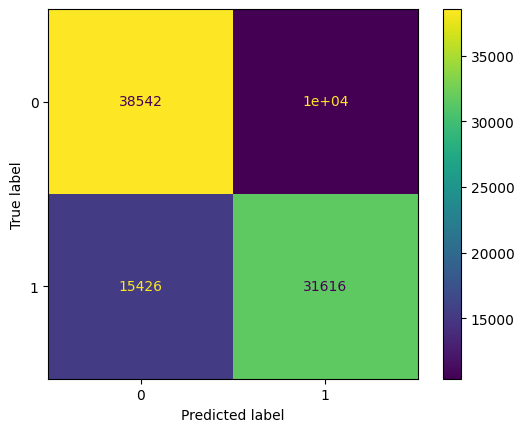

In [10]:
"""
Evaluate the model
Using :
- Mean Absolute Error
- Mean Squared Error
- Root Mean Squared Error
- R^2 Score
- F1 Score
- Precision Score
- Recall Score
"""

mae = mean_absolute_error(y_test, y_pred_best)
mse = mean_squared_error(y_test, y_pred_best)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_best)
f1 = f1_score(y_test, y_pred_best)
precision = precision_score(y_test, y_pred_best)
recall = recall_score(y_test, y_pred_best)

print("********** CATBOOST SCORES **********")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R^2 Score: {r2:.4f}")
print(f"f1 Score: {f1:.4f}")
print(f"Precision Score: {precision:.4f}")
print(f"Recall Score: {recall:.4f}")
print("**********************************")

# Get the final accuracy and the confusion matrix
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print("********** CATBOOST ACCURACY **********")
print(f"Accuracy: ", accuracy)
print("**********************************")

# Plot confusion matrix
cmatrix_display = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=model.classes_)
cmatrix_display.plot()

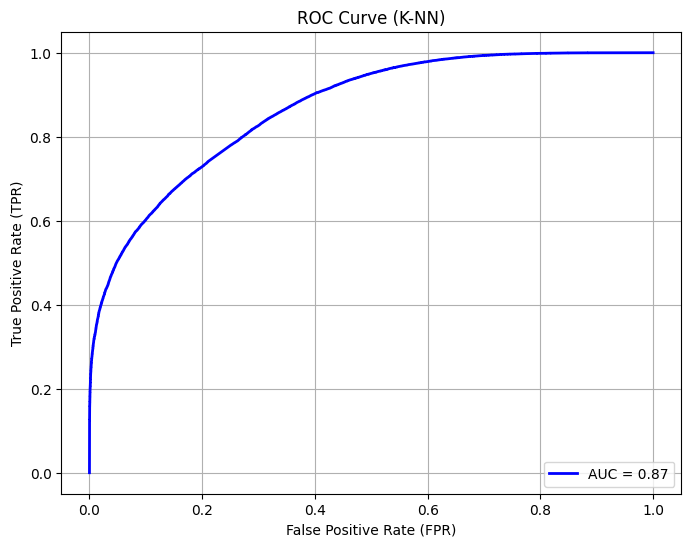

AUC-ROC Score: 0.8674


In [11]:
"""
ROC Curve & AUC-ROC Score
"""

# Get the probability estimates for the positive class
y_probs = best_model.predict_proba(X_test)[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

# Compute AUC-ROC score
auc_roc = roc_auc_score(y_test, y_probs)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'AUC = {auc_roc:.2f}')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve (K-NN)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Print AUC-ROC score
print(f"AUC-ROC Score: {auc_roc:.4f}")